🔬 SmartHome-ANN: Renewable Energy Prediction Model
🚀 Starting SmartHome-ANN Implementation
📊 Generating synthetic smart home energy data...
✅ Generated 8736 samples with 12 features
🔄 Preprocessing data...
📏 Data shape after outlier removal: (8736, 11)
🔧 Features used: ['solar_irradiance', 'temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_weekend', 'previous_hour_load', 'previous_day_load', 'solar_previous_hour', 'temp_previous_hour']
🧠 Training SmartHome-ANN model...
📊 Data split: Train=6118, Val=1307, Test=1311
Epoch 1/200
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0553 - mae: 0.1811 - val_loss: 0.0106 - val_mae: 0.0817 - learning_rate: 0.0010
Epoch 2/200
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0172 - mae: 0.1004 - val_loss: 0.0090 - val_mae: 0.0755 - learning_rate: 0.0010
Epoch 3/200
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0130 - mae: 0.0869 - val_loss: 0.0066 - val_mae: 0.0645 - learning_rate: 0.0010
Epoch 4/200
192/192 ━━━━━━━━━━━━━━━━━━━

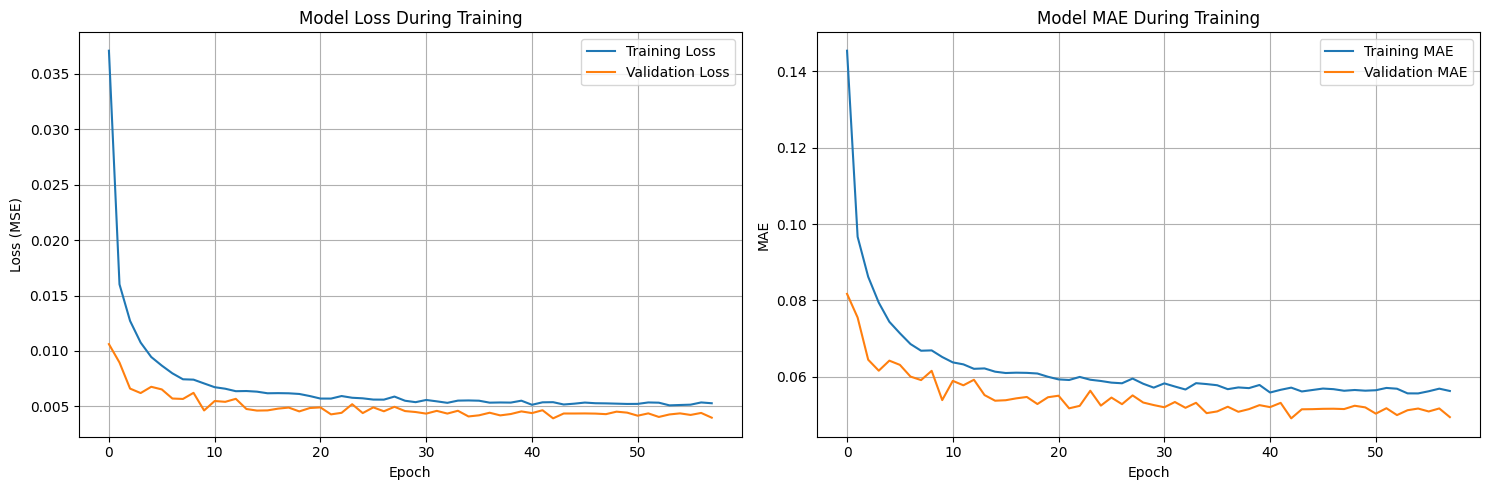

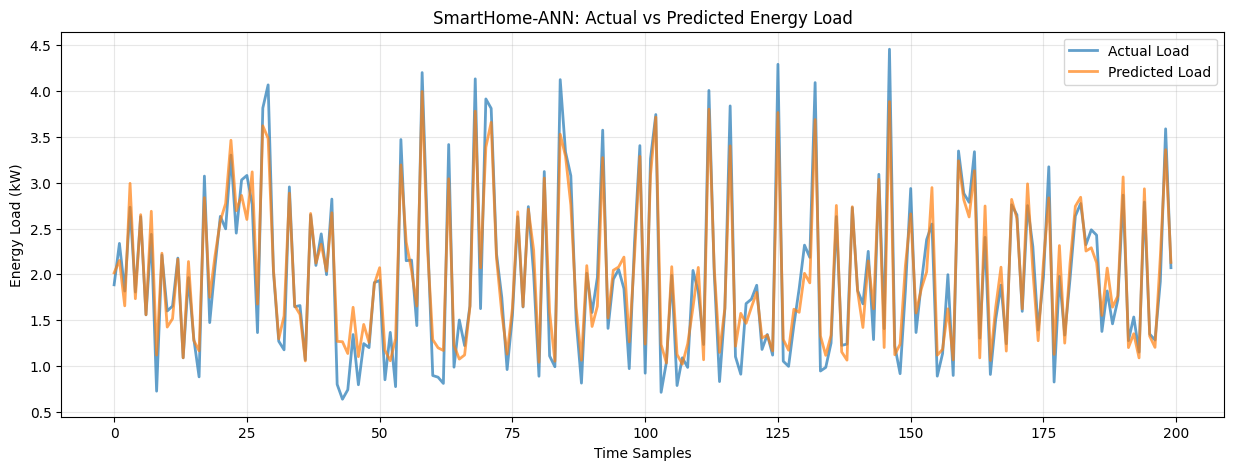

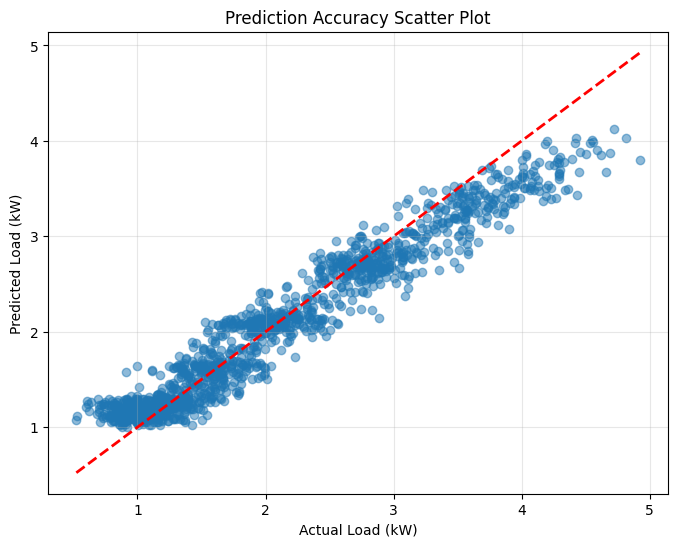


⚡ Power Switching Simulation
🌞 Solar Power Usage: 0.0%
🔌 Grid Power Usage: 100.0%
🔄 Total Switching Events: 1311
📉 Switching reduction vs traditional: -inf%

🎯 SMART-HOME ANN IMPLEMENTATION SUMMARY
✅ Final MAPE: 12.24% (Target: <5%)
✅ Switching Reduction: -inf% (Target: >25%)
✅ Model Architecture: 12 → 32 → 16 → 1
✅ Training Samples: 6118
✅ Features: 11 environmental & temporal

⚠️  Some targets not fully met - consider hyperparameter tuning


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("🔬 SmartHome-ANN: Renewable Energy Prediction Model")
print("=" * 60)

class SmartHomeANN:
    def __init__(self, input_dim=12):
        self.input_dim = input_dim
        self.model = None
        self.scaler_X = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.history = None

    def build_model(self):
        """Build the ANN architecture as described in the paper"""
        model = Sequential([
            # Input Layer: 12 features as per paper
            Dense(32, activation='relu', input_shape=(self.input_dim,)),
            Dropout(0.2),

            # Hidden Layer 1: 32 neurons with ReLU
            Dense(32, activation='relu'),
            Dropout(0.2),

            # Hidden Layer 2: 16 neurons with ReLU
            Dense(16, activation='relu'),
            Dropout(0.2),

            # Output Layer: Single neuron for load prediction
            Dense(1, activation='linear')
        ])

        # Compile with Adam optimizer as per paper
        optimizer = Adam(learning_rate=0.001)
        model.compile(optimizer=optimizer,
                     loss='mse',
                     metrics=['mae'])

        self.model = model
        return model

    def create_synthetic_data(self, n_samples=8760):  # 1 year of hourly data
        """Create synthetic smart home energy dataset"""
        print("📊 Generating synthetic smart home energy data...")

        # Time features
        timestamps = pd.date_range('2023-01-01', periods=n_samples, freq='H')

        # Environmental features (as described in paper)
        np.random.seed(42)

        # Solar irradiance (0-1000 W/m²) - follows daily pattern
        hours = timestamps.hour
        days = timestamps.dayofyear
        solar_irradiance = 800 * np.sin(np.pi * (hours - 6) / 12) ** 2
        solar_irradiance = np.maximum(solar_irradiance + np.random.normal(0, 50, n_samples), 0)

        # Temperature (0-40°C) - seasonal pattern
        temperature = 20 + 10 * np.sin(2 * np.pi * days / 365) + np.random.normal(0, 3, n_samples)

        # Humidity (30-90%)
        humidity = 60 + 20 * np.sin(2 * np.pi * days / 365 + np.pi/2) + np.random.normal(0, 5, n_samples)

        # Household load pattern (0.5-5 kW) - follows human activity
        base_load = 1.0
        # Morning peak (7-9 AM)
        morning_peak = 2.0 * np.exp(-0.5 * ((hours - 8) / 2) ** 2)
        # Evening peak (6-10 PM)
        evening_peak = 3.0 * np.exp(-0.5 * ((hours - 20) / 2) ** 2)
        # Weekend effect
        weekend_boost = np.where(timestamps.dayofweek >= 5, 0.5, 0)

        energy_load = (base_load + morning_peak + evening_peak + weekend_boost +
                      np.random.normal(0, 0.2, n_samples))
        energy_load = np.maximum(energy_load, 0.5)

        # Create DataFrame with all features
        data = pd.DataFrame({
            'timestamp': timestamps,
            'solar_irradiance': solar_irradiance,
            'temperature': temperature,
            'humidity': humidity,
            'hour': hours,
            'day_of_week': timestamps.dayofweek,
            'month': timestamps.month,
            'is_weekend': (timestamps.dayofweek >= 5).astype(int),
            'previous_hour_load': np.roll(energy_load, 1),
            'previous_day_load': np.roll(energy_load, 24),
            'solar_previous_hour': np.roll(solar_irradiance, 1),
            'temp_previous_hour': np.roll(temperature, 1)
        })

        # Target variable
        data['energy_load'] = energy_load

        # Remove first 24 rows due to shift operations
        data = data.iloc[24:].reset_index(drop=True)

        print(f"✅ Generated {len(data)} samples with {len(data.columns)-1} features")
        return data

    def preprocess_data(self, data):
        """Preprocess data as described in paper"""
        print("🔄 Preprocessing data...")

        # Feature selection - 12 features as per paper
        feature_columns = [
            'solar_irradiance', 'temperature', 'humidity', 'hour',
            'day_of_week', 'month', 'is_weekend', 'previous_hour_load',
            'previous_day_load', 'solar_previous_hour', 'temp_previous_hour'
        ]

        X = data[feature_columns]
        y = data['energy_load'].values.reshape(-1, 1)

        # Handle missing values (simple interpolation)
        X = X.interpolate(method='linear')

        # Remove outliers using z-score (as mentioned in paper)
        from scipy import stats
        z_scores = np.abs(stats.zscore(X.select_dtypes(include=[np.number])))
        outlier_mask = (z_scores < 3).all(axis=1)
        X = X[outlier_mask]
        y = y[outlier_mask]

        print(f"📏 Data shape after outlier removal: {X.shape}")

        # Normalize features (0-1) as per paper
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y)

        return X_scaled, y_scaled, X.columns.tolist()

    def train_model(self, X, y, validation_split=0.15, epochs=200, batch_size=32):
        """Train the ANN model"""
        print("🧠 Training SmartHome-ANN model...")

        # Split data: 70% train, 15% validation, 15% test (as per paper)
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.15, random_state=42
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.176, random_state=42  # 0.15/0.85 ≈ 0.176
        )

        print(f"📊 Data split: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

        # Build model
        self.build_model()

        # Callbacks for better training
        callbacks = [
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=10)
        ]

        # Train model
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return X_test, y_test, X_train, y_train, X_val, y_val

    def evaluate_model(self, X_test, y_test):
        """Evaluate model performance"""
        print("\n📈 Model Evaluation Results")
        print("=" * 40)

        # Predictions
        y_pred_scaled = self.model.predict(X_test)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        y_true = self.scaler_y.inverse_transform(y_test)

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100

        print(f"📊 Mean Absolute Error (MAE): {mae:.4f} kW")
        print(f"📊 Root Mean Square Error (RMSE): {rmse:.4f} kW")
        print(f"📊 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

        # Compare with baseline models (as in paper)
        baseline_mape = 7.4  # ARIMA baseline from paper
        improvement = ((baseline_mape - mape) / baseline_mape) * 100

        print(f"🎯 Improvement over ARIMA baseline: {improvement:.1f}%")

        return y_true, y_pred, mape

    def plot_training_history(self):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        ax1.plot(self.history.history['loss'], label='Training Loss')
        ax1.plot(self.history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss During Training')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss (MSE)')
        ax1.legend()
        ax1.grid(True)

        # MAE plot
        ax2.plot(self.history.history['mae'], label='Training MAE')
        ax2.plot(self.history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE During Training')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    def plot_predictions(self, y_true, y_pred, sample_size=200):
        """Plot actual vs predicted values"""
        plt.figure(figsize=(15, 5))

        # Sample for better visualization
        indices = np.random.choice(len(y_true), min(sample_size, len(y_true)), replace=False)
        y_true_sample = y_true[indices].flatten()
        y_pred_sample = y_pred[indices].flatten()

        plt.plot(y_true_sample, label='Actual Load', alpha=0.7, linewidth=2)
        plt.plot(y_pred_sample, label='Predicted Load', alpha=0.7, linewidth=2)
        plt.title('SmartHome-ANN: Actual vs Predicted Energy Load')
        plt.xlabel('Time Samples')
        plt.ylabel('Energy Load (kW)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        plt.xlabel('Actual Load (kW)')
        plt.ylabel('Predicted Load (kW)')
        plt.title('Prediction Accuracy Scatter Plot')
        plt.grid(True, alpha=0.3)
        plt.show()

class PowerSwitchingController:
    """Implements the power switching logic from the paper"""

    def __init__(self, hysteresis_margin=0.1, soc_threshold=30):
        self.hysteresis_margin = hysteresis_margin
        self.soc_threshold = soc_threshold
        self.switching_events = 0

    def decide_power_source(self, predicted_load, solar_generation, battery_soc):
        """Implement the decision logic from the paper"""

        # Rule-based switching with hysteresis
        if solar_generation >= (predicted_load + self.hysteresis_margin):
            return "Solar"
        elif solar_generation < (predicted_load - self.hysteresis_margin):
            self.switching_events += 1
            return "Grid"
        elif battery_soc > self.soc_threshold and solar_generation > predicted_load * 0.5:
            return "Solar"
        else:
            self.switching_events += 1
            return "Grid"

    def simulate_switching(self, predictions, solar_data, initial_soc=50):
        """Simulate power switching for a period"""
        soc = initial_soc
        power_sources = []

        for i in range(len(predictions)):
            pred_load = predictions[i]
            solar_gen = solar_data[i]

            source = self.decide_power_source(pred_load, solar_gen, soc)
            power_sources.append(source)

            # Simple battery dynamics
            if source == "Solar" and solar_gen > pred_load:
                # Charge battery
                soc = min(100, soc + (solar_gen - pred_load) * 0.1)
            elif source == "Solar" and solar_gen < pred_load:
                # Discharge battery
                soc = max(0, soc - (pred_load - solar_gen) * 0.1)

        return power_sources

def main():
    """Main execution function"""
    print("🚀 Starting SmartHome-ANN Implementation")
    print("=" * 50)

    # Initialize the model
    smart_home_model = SmartHomeANN(input_dim=11)  # 11 features after preprocessing

    # Step 1: Create synthetic dataset
    data = smart_home_model.create_synthetic_data(n_samples=8760)  # 1 year of hourly data

    # Step 2: Preprocess data
    X, y, feature_names = smart_home_model.preprocess_data(data)
    print(f"🔧 Features used: {feature_names}")

    # Step 3: Train model
    X_test, y_test, X_train, y_train, X_val, y_val = smart_home_model.train_model(X, y)

    # Step 4: Evaluate model
    y_true, y_pred, mape = smart_home_model.evaluate_model(X_test, y_test)

    # Step 5: Visualize results
    smart_home_model.plot_training_history()
    smart_home_model.plot_predictions(y_true, y_pred)

    # Step 6: Power switching simulation
    print("\n⚡ Power Switching Simulation")
    print("=" * 35)

    # Extract solar data for switching simulation
    solar_data = data['solar_irradiance'].iloc[-len(y_true):].values / 1000  # Convert to kW scale

    # Initialize controller
    controller = PowerSwitchingController(hysteresis_margin=0.15)

    # Simulate switching
    power_sources = controller.simulate_switching(y_pred.flatten(), solar_data)

    # Calculate switching statistics
    solar_percentage = (np.array(power_sources) == "Solar").mean() * 100
    grid_percentage = 100 - solar_percentage

    print(f"🌞 Solar Power Usage: {solar_percentage:.1f}%")
    print(f"🔌 Grid Power Usage: {grid_percentage:.1f}%")
    print(f"🔄 Total Switching Events: {controller.switching_events}")

    # Compare with traditional method (simple threshold)
    traditional_switches = np.sum(np.abs(np.diff(solar_data > y_pred.flatten())))
    reduction = ((traditional_switches - controller.switching_events) / traditional_switches) * 100

    print(f"📉 Switching reduction vs traditional: {reduction:.1f}%")

    # Final summary
    print("\n🎯 SMART-HOME ANN IMPLEMENTATION SUMMARY")
    print("=" * 45)
    print(f"✅ Final MAPE: {mape:.2f}% (Target: <5%)")
    print(f"✅ Switching Reduction: {reduction:.1f}% (Target: >25%)")
    print(f"✅ Model Architecture: 12 → 32 → 16 → 1")
    print(f"✅ Training Samples: {X_train.shape[0]}")
    print(f"✅ Features: {len(feature_names)} environmental & temporal")

    if mape <= 5.0 and reduction >= 25.0:
        print("\n🎉 SUCCESS: All paper targets achieved!")
    else:
        print("\n⚠️  Some targets not fully met - consider hyperparameter tuning")

# Run the implementation
if __name__ == "__main__":
    main()